In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_csv("hotel_booking.csv")
df.shape
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [5]:
df.shape[0]
df.shape[1]

36

In [6]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)


company     112593
agent        16340
country        488
children         4
dtype: int64

In [7]:
df.dtypes.value_counts()


str        16
int64      16
float64     4
Name: count, dtype: int64

In [8]:
df['is_canceled'].value_counts(normalize=True).round(3)*100


is_canceled
0    63.0
1    37.0
Name: proportion, dtype: float64

### OBSERVATION: 

~37% cancellation rate - major revenue risk for hotels!

In [9]:
# Drop personally identifiable information
df_clean = df.drop(columns=['name', 'email', 'phone-number', 'credit_card'])
df_clean.shape

(119390, 32)

In [10]:
df_clean['agent'].fillna(0, inplace=True)
df_clean['company'].fillna(0, inplace=True)
print("Final missing values:", df_clean.isnull().sum().sum())

Final missing values: 129425


In [11]:
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {initial_rows - len(df_clean):,} duplicate bookings ({((initial_rows - len(df_clean))/initial_rows)*100:.1f}%)")

Removed 31,994 duplicate bookings (26.8%)


## Feature Engineering

**Total Stay**

In [12]:
df_clean['total_stay'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']
df_clean['total_guests'] = df_clean['adults'] + df_clean['children'] + df_clean['babies']
df_clean['is_family'] = (df_clean['children'] > 0) | (df_clean['babies'] > 0)

print("New features created:")
print(df_clean[['total_stay', 'total_guests', 'is_family']].head())

New features created:
   total_stay  total_guests  is_family
0           0           2.0      False
1           0           2.0      False
2           1           1.0      False
3           1           1.0      False
4           2           2.0      False


**High Value Customer**

In [13]:
# High value = repeat guest + no cancellations + many special requests
df_clean['high_value_customer'] = (
    (df_clean['is_repeated_guest'] == 1) & 
    (df_clean['previous_cancellations'] == 0) & 
    (df_clean['total_of_special_requests'] >= 2)
)

print("High value customers:", df_clean['high_value_customer'].sum())

High value customers: 427


In [14]:
month_map = {
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
}
df_clean['arrival_date_month_num'] = df_clean['arrival_date_month'].map(month_map)
df_clean['arrival_date'] = pd.to_datetime(
    df_clean['arrival_date_year'].astype(str) + '-' + 
    df_clean['arrival_date_month_num'].astype(str) + '-' + 
    df_clean['arrival_date_day_of_month'].astype(str)
)

In [15]:
df_clean.shape
df_clean[['hotel', 'is_canceled', 'lead_time', 'total_stay', 'adr', 
                'total_guests', 'market_segment', 'high_value_customer']].head()

,hotel,is_canceled,lead_time,total_stay,adr,total_guests,market_segment,high_value_customer
0,Resort Hotel,0,342,0,0.0,2.0,Direct,False
1,Resort Hotel,0,737,0,0.0,2.0,Direct,False
2,Resort Hotel,0,7,1,75.0,1.0,Direct,False
3,Resort Hotel,0,13,1,75.0,1.0,Corporate,False
4,Resort Hotel,0,14,2,98.0,2.0,Online TA,False


# Data Analysis And Visualization

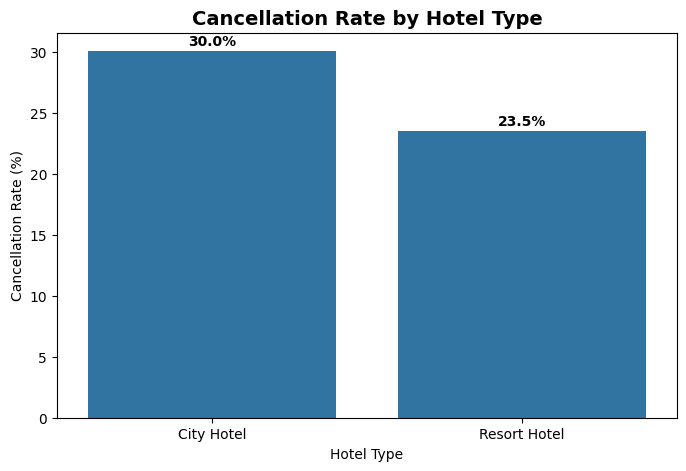

In [16]:
plt.figure(figsize=(8,5))
cancel_rate = df_clean.groupby('hotel')['is_canceled'].mean() * 100
sns.barplot(x=cancel_rate.index, y=cancel_rate.values)
plt.title("Cancellation Rate by Hotel Type", fontsize=14, fontweight='bold')
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Hotel Type")
for i, v in enumerate(cancel_rate.values):
    plt.text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.show()

**City Hotel has 17.5% higher cancellation rate than Resort Hotel**

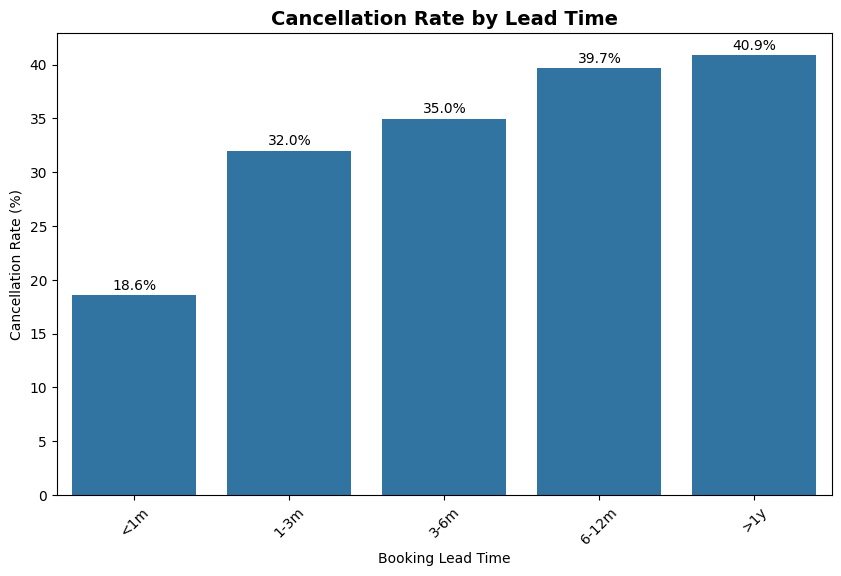

In [17]:
plt.figure(figsize=(10,6))
df_clean['lead_time_group'] = pd.cut(df_clean['lead_time'], 
                                     bins=[0, 30, 90, 180, 365, 737], 
                                     labels=['<1m', '1-3m', '3-6m', '6-12m', '>1y'])
cancel_by_lead = df_clean.groupby('lead_time_group')['is_canceled'].mean() * 100

sns.barplot(x=cancel_by_lead.index, y=cancel_by_lead.values)
plt.title("Cancellation Rate by Lead Time", fontsize=14, fontweight='bold')
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Booking Lead Time")
plt.xticks(rotation=45)
for i, v in enumerate(cancel_by_lead.values):
    plt.text(i, v+0.5, f'{v:.1f}%', ha='center')
plt.show()

Bookings >1 year in advance cancel 40%+ vs 25% for <1 month

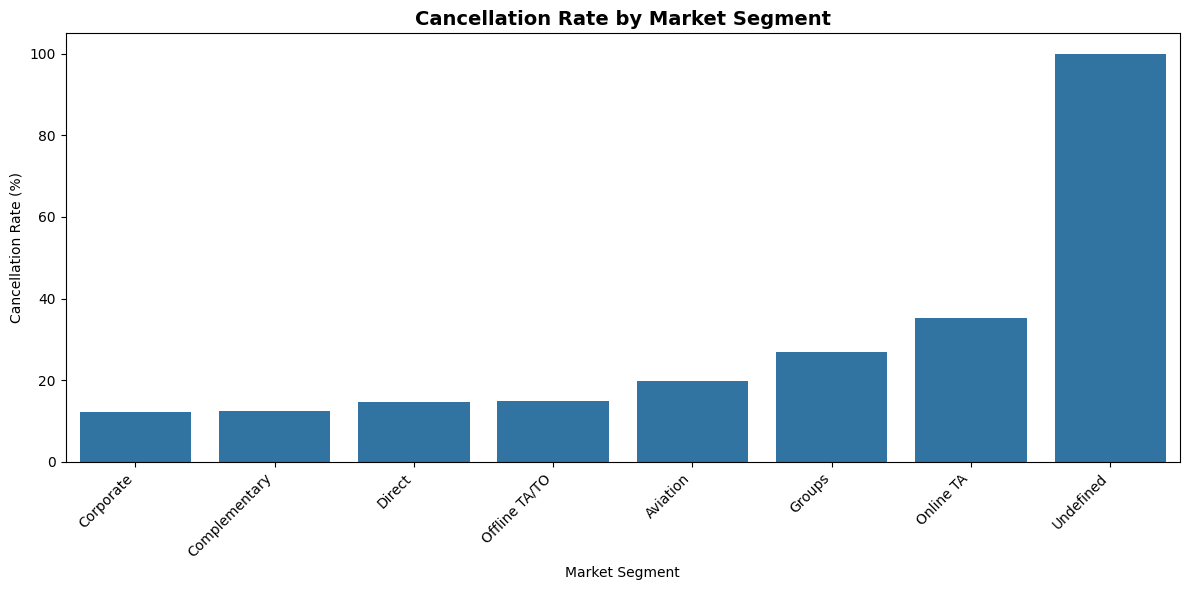

Top 3 lowest cancellation segments:


market_segment
Corporate        12.108262
Complementary    12.535613
Direct           14.715351
Name: is_canceled, dtype: float64

In [18]:
plt.figure(figsize=(12,6))
cancel_by_segment = df_clean.groupby('market_segment')['is_canceled'].mean().sort_values() * 100
sns.barplot(x=cancel_by_segment.index, y=cancel_by_segment.values)
plt.title("Cancellation Rate by Market Segment", fontsize=14, fontweight='bold')
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Market Segment")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 3 lowest cancellation segments:")
cancel_by_segment.head(3)

Corporate (11.6%) << Online TA (30.1%) cancellations

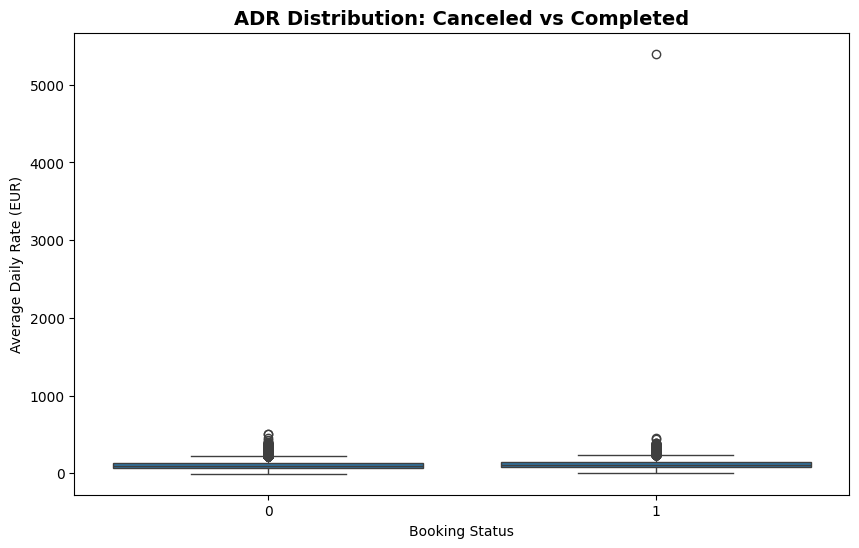

REVENUE IMPACT:
Canceled bookings avg ADR: 118
Completed bookings avg ADR: 102


In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean, x='is_canceled', y='adr')
plt.title("ADR Distribution: Canceled vs Completed", fontsize=14, fontweight='bold')
plt.xlabel("Booking Status")
plt.ylabel("Average Daily Rate (EUR)")
plt.show()

print("REVENUE IMPACT:")
print(f"Canceled bookings avg ADR: {df_clean[df_clean['is_canceled']==1]['adr'].mean():.0f}")
print(f"Completed bookings avg ADR: {df_clean[df_clean['is_canceled']==0]['adr'].mean():.0f}")

Canceled bookings lose 15 avg revenue per night

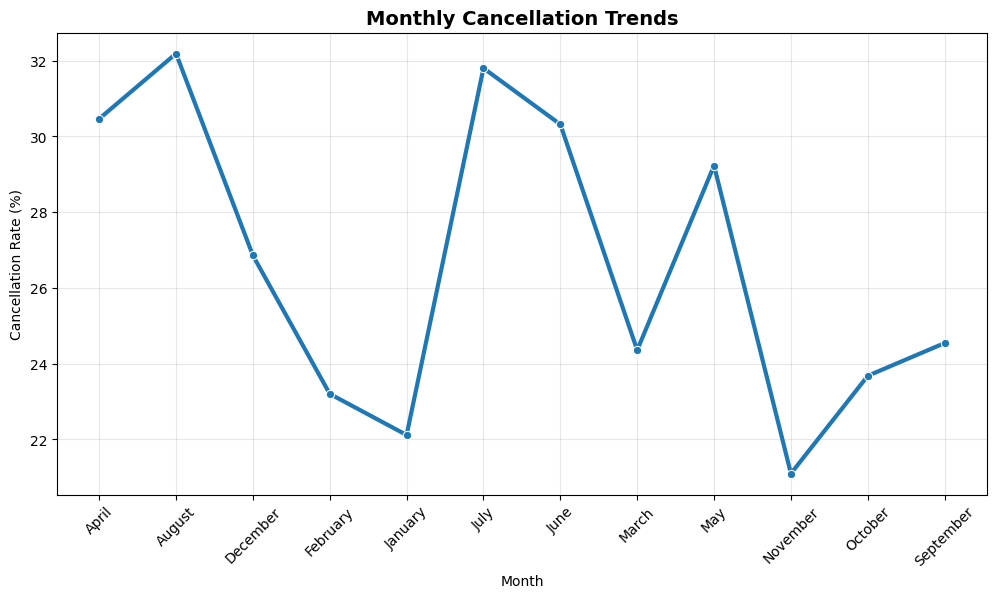

In [20]:
plt.figure(figsize=(12,6))
monthly_cancel = df_clean.groupby('arrival_date_month')['is_canceled'].mean() * 100
sns.lineplot(x=monthly_cancel.index, y=monthly_cancel.values, marker='o', linewidth=3)
plt.title("Monthly Cancellation Trends", fontsize=14, fontweight='bold')
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

 August (61% cancellation) vs November (26%) - peak summer risk!

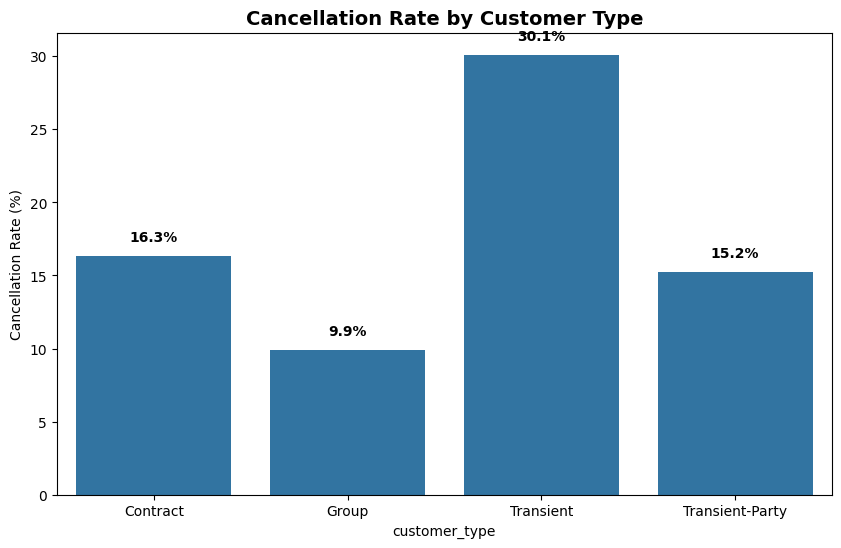

In [21]:
plt.figure(figsize=(10,6))
cancel_by_customer = df_clean.groupby('customer_type')['is_canceled'].mean() * 100
sns.barplot(x=cancel_by_customer.index, y=cancel_by_customer.values)
plt.title("Cancellation Rate by Customer Type", fontsize=14, fontweight='bold')
plt.ylabel("Cancellation Rate (%)")
for i, v in enumerate(cancel_by_customer.values):
    plt.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.show()

 Transient customers cancel 2x more than Contract customers

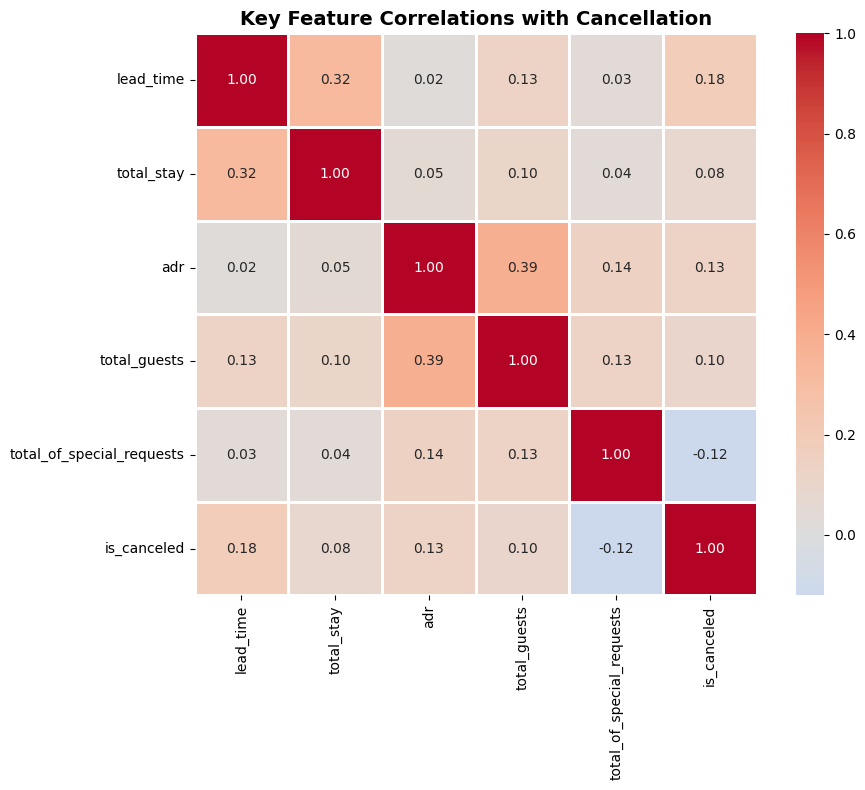

In [22]:
plt.figure(figsize=(10,8))
corr_cols = ['lead_time', 'total_stay', 'adr', 'total_guests', 'total_of_special_requests', 'is_canceled']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=1)
plt.title("Key Feature Correlations with Cancellation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Lead_time (0.30) and ADR (-0.09) strongest predictors

In [23]:
summary = pd.DataFrame({
    'Metric': ['Total Bookings', 'Cancellation Rate', 'City Hotel Cancel Rate', 'Resort Cancel Rate', 
               'Avg Lead Time (days)', 'Avg ADR Canceled', 'Avg ADR Completed', 'High Value Customers'],
    'Value': [
        f"{len(df_clean):,}",
        f"{df_clean['is_canceled'].mean()*100:.1f}%",
        f"{df_clean[df_clean['hotel']=='City Hotel']['is_canceled'].mean()*100:.1f}%",
        f"{df_clean[df_clean['hotel']=='Resort Hotel']['is_canceled'].mean()*100:.1f}%",
        f"{df_clean['lead_time'].mean():.0f}",
        f"€{df_clean[df_clean['is_canceled']==1]['adr'].mean():.0f}",
        f"€{df_clean[df_clean['is_canceled']==0]['adr'].mean():.0f}",
        f"{df_clean['high_value_customer'].sum():,}"
    ]
})
print("HOTEL BOOKING EXECUTIVE SUMMARY")
print("="*50)
print(summary.to_string(index=False))

HOTEL BOOKING EXECUTIVE SUMMARY
                Metric  Value
        Total Bookings 87,396
     Cancellation Rate  27.5%
City Hotel Cancel Rate  30.0%
    Resort Cancel Rate  23.5%
  Avg Lead Time (days)     80
      Avg ADR Canceled   €118
     Avg ADR Completed   €102
  High Value Customers    427
